xbar =  1.0057452854288194
s =  10.032143279686828


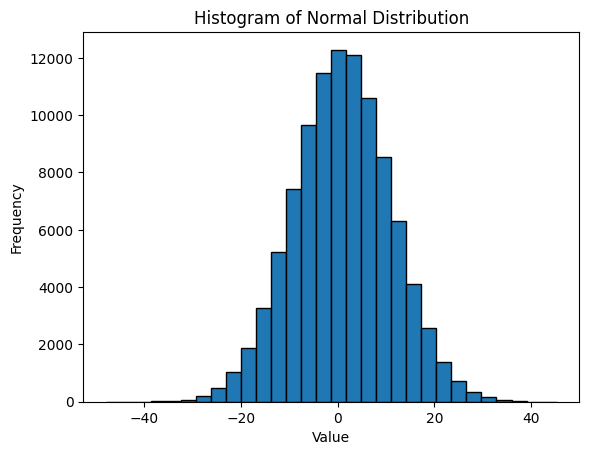

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Generate data from a normal distribution
data = (np.random.randn(100000) + .1) * np.sqrt(100)

print('xbar = ', np.mean(data))
print('s = ', np.std(data))

# Create a histogram
plt.hist(data, bins=30, edgecolor='black')
plt.title('Histogram of Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

# True population parameters
TRUE_MEAN = 0.1
POP_STD = np.sqrt(100)
POP_SIZE = 100000

# Generate population data, keep fixed for reproducibility
np.random.seed(42)  # Ensure reproducibility
data = (np.random.randn(POP_SIZE) + TRUE_MEAN) * POP_STD

pop_mean = np.mean(data)
pop_std = np.std(data)

print('Population mean (should be close to 0.1):', TRUE_MEAN)
print('Sampled population mean:', pop_mean)
print('Sampled population std:', pop_std)

def plot_with_points(up_to_index):
    # up_to_index goes from 0 to 1000
    max_index = min(up_to_index, 1000, len(data)-1)
    if max_index < 1:
        max_index = 1

    indices = np.arange(0, max_index)
    points = data[indices]
    points_sample_mean = np.mean(points)

    # Second small sample for generality (from full population)
    sample_n = 25
    sample2_indices = np.random.choice(np.arange(len(data)), size=sample_n, replace=False)
    sample2 = data[sample2_indices]
    sample2_mean = np.mean(sample2)

    plt.figure(figsize=(10,6))
    plt.scatter(indices, points, alpha=0.5, s=10, label="Data Points (0:index)")
    plt.axhline(TRUE_MEAN, color='black', linestyle='--', linewidth=2, label=f"True Mean = {TRUE_MEAN:.2f}")
    plt.axhline(points_sample_mean, color='blue', linestyle='-', linewidth=2, label=f"Sample Mean (Shown Indices) = {points_sample_mean:.2f}")

    plt.title(f"Scatter Plot (Showing Data[0:{max_index}])\nPoints Shown: {max_index}")
    plt.xlabel("Index (from 0)")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

    # Highlight 5 random draws from shown points (if enough shown)
    plt.figure(figsize=(10, 6))
    plt.scatter(indices, points, alpha=0.5, s=10, label="Data Points (0:index)")
    if max_index >= 5:
        draws_indices = np.random.choice(indices, size=5, replace=False)
        draws_values = data[draws_indices]
        plt.scatter(draws_indices, draws_values, color='orange', s=50, marker='x', label="Random Draws")
        for i, (idx, val) in enumerate(zip(draws_indices, draws_values)):
            plt.annotate(f"Draw {i+1}", (idx, val), textcoords="offset points", xytext=(0,10), ha='center', color='orange')

    plt.axhline(TRUE_MEAN, color='black', linestyle='--', linewidth=2, label=f"True Mean = {TRUE_MEAN:.2f}")
    plt.axhline(points_sample_mean, color='blue', linestyle='-', linewidth=2, label=f"Sample Mean (Shown Indices) = {points_sample_mean:.2f}")
    plt.axhline(sample2_mean, color='green', linestyle='-', linewidth=2, label=f"Sample Mean 2 (Random 25) = {sample2_mean:.2f}")

    plt.title(f"Scatter Plot with Random Draws, True Mean, and Sample Means\nIndices 0:{max_index}")
    plt.xlabel("Index (from 0)")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

interact(
    plot_with_points,
    up_to_index=IntSlider(value=100, min=0, max=1000, step=1, description='Show up to index:')
)

Population mean (should be close to 0.1): 0.1
Sampled population mean: 1.0096686814094962
Sampled population std: 10.009009542948904


interactive(children=(IntSlider(value=100, description='Show up to index:', max=1000), Output()), _dom_classes…

<function __main__.plot_with_points(up_to_index)>

: 